## Nonlinear regression toy example

This is another example using synthetic data, this time a regression problem.

In [1]:
import numpy as np
from sklearn.pipeline import make_pipeline

from matplotlib import pyplot as plt

%config InlineBackend.figure_format = 'retina' 
plt.style.use('bmh')

We make some synthetic data. In this case, we have one input variable and one output.

In [2]:
def make_data():
    N = 2000
    X = 0.5*np.random.normal(size=N)+0.35

    Xt = 0.75*X-0.35
    X = X.reshape((N,1))

    Y = -(8 * Xt**2 + 0.1*Xt + 0.1) + 0.05 * np.random.normal(size=N)
    Y = np.exp(Y) + 0.05 * np.random.normal(size=N)
    Y /= max(np.abs(Y))
    return X, Y

np.random.seed(0)
X, Y = make_data()

Plot the data.

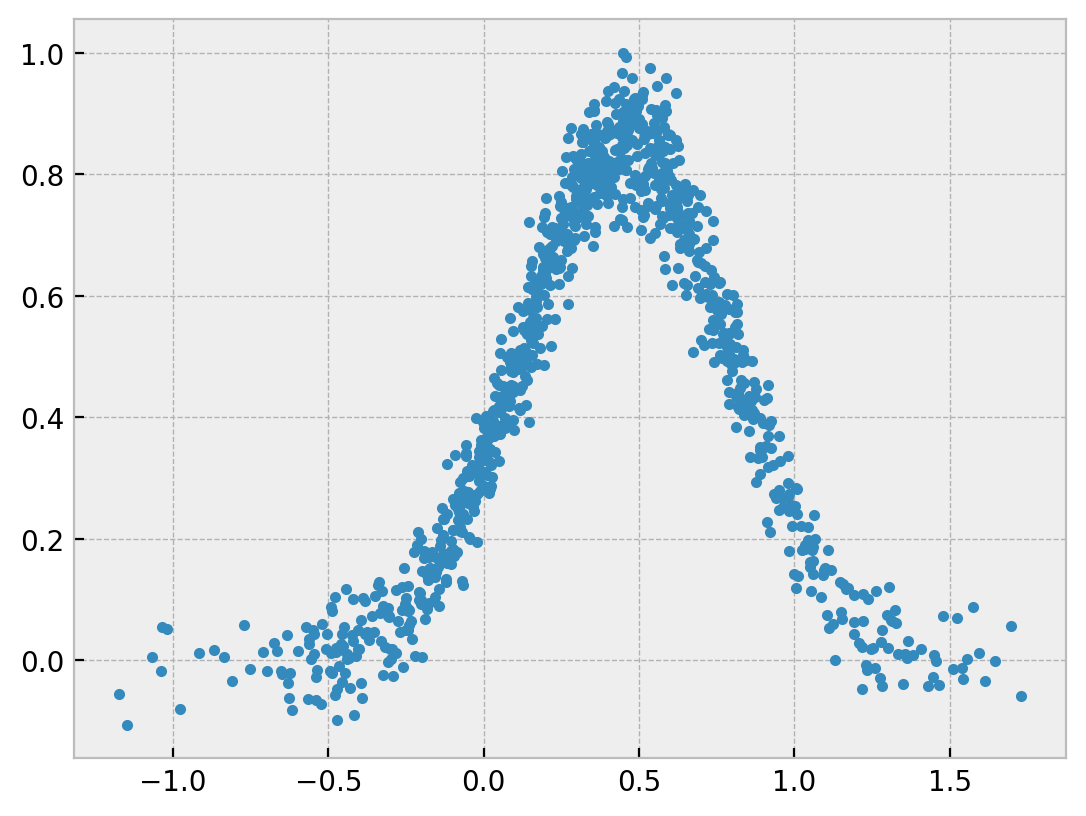

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.5, random_state=0)

plt.plot(Xtest[:,0], Ytest, '.');

In [4]:
#plt.plot(Xtrain[:,0], Ytrain, '*');

This data has a nonlinear relationship, so a linear model (in this case `Ridge`) won't work very well. The $R^2$ score is close to zero.

We plot the predicted outputs (in red).

(0.08555291732808022, 0.05965631801655258)

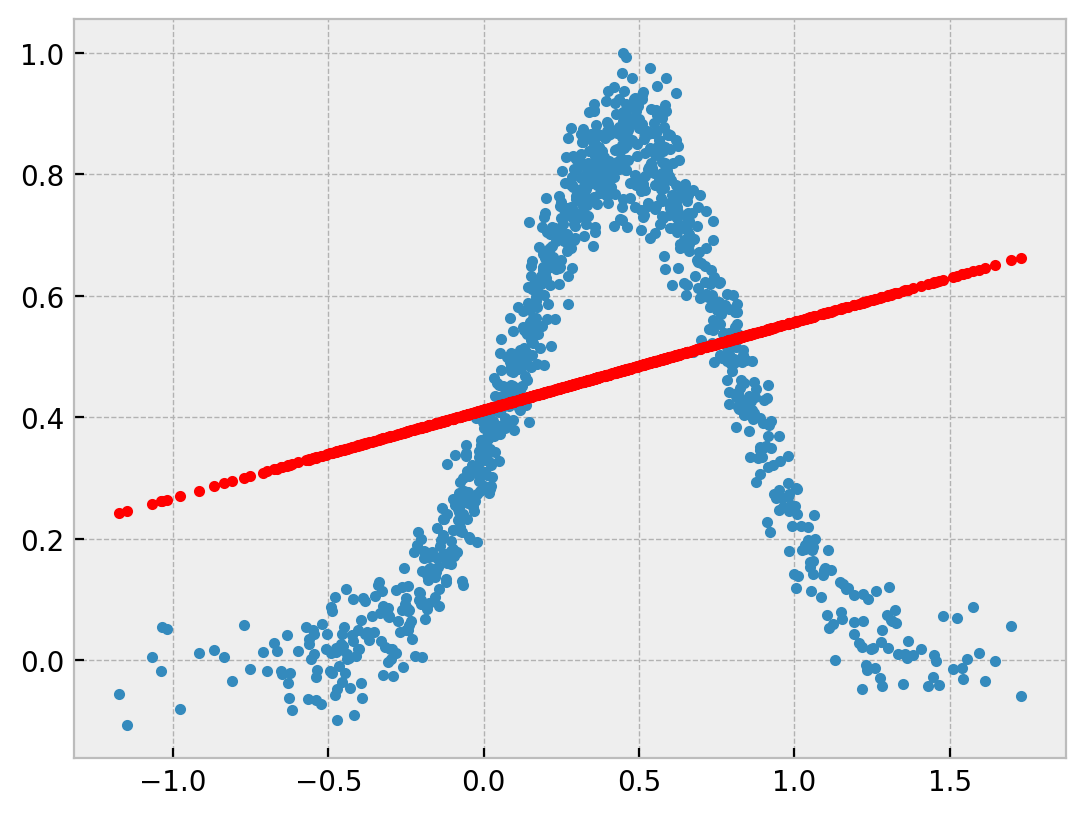

In [5]:
from sklearn.linear_model import Ridge

ridge = Ridge()
ridge.fit(Xtrain, Ytrain)

Yguess = ridge.predict(Xtest)

plt.plot(Xtest[:,0], Ytest, '.')
plt.plot(Xtest[:,0], Yguess, 'r.')

mean_squared_error(Ytest, Yguess), r2_score(Ytest, Yguess)

### Training a neural network regressor

We train a regression model using scikit-learn's [`MLPRegressor`](http://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html). This model is much better at capturing the nonlinear relationship between the input and the output, which is reflected in the $R^2$ score and in the plot.

When we use the ReLU as the activation function in the hidden layer, we get a piecewise linear regressor; if we switch to a `tanh` or `logistic` activation, we will get a more smooth shape.

(0.02209001342752656, 0.7572005115635461)

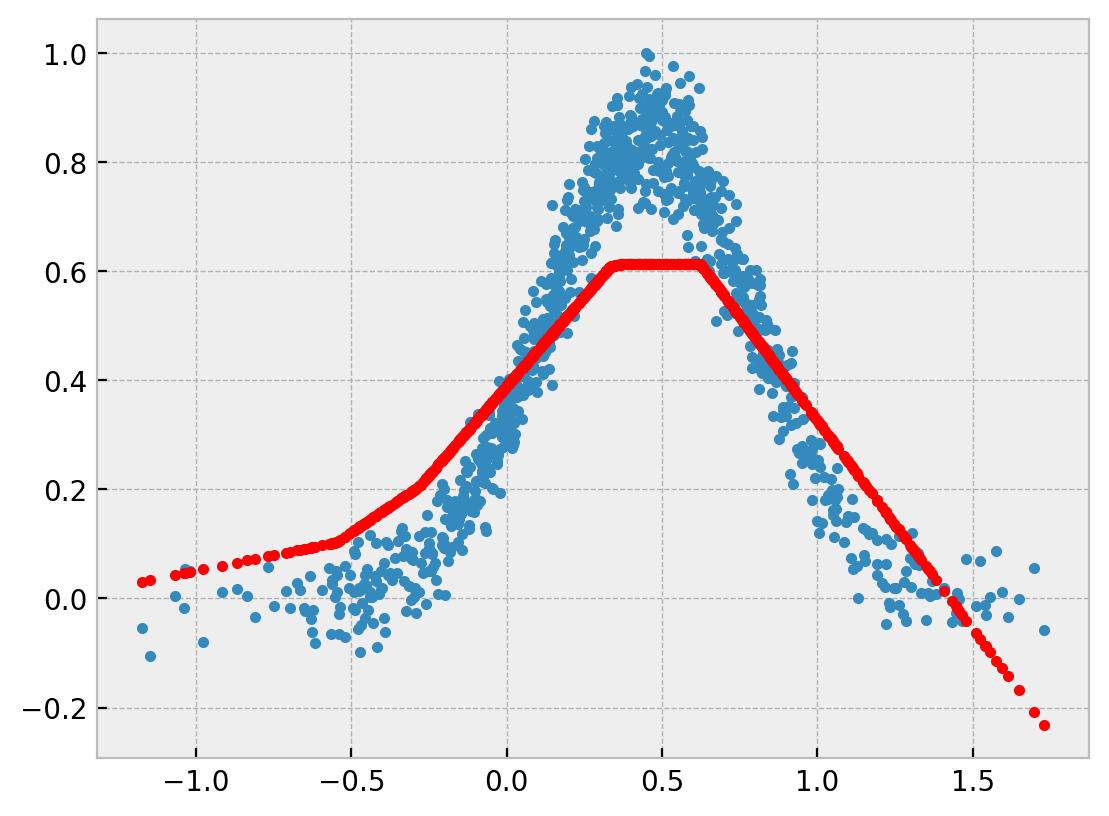

In [6]:
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(random_state=0, activation='relu', hidden_layer_sizes=(8,4), max_iter=500)

#mlp = MLPRegressor(random_state=0, activation='tanh', hidden_layer_sizes=(12,8,4)) #(16,8))

mlp.fit(Xtrain, Ytrain)

Yguess = mlp.predict(Xtest)

plt.plot(Xtest[:,0], Ytest, '.')
plt.plot(Xtest[:,0], Yguess, 'r.')

mean_squared_error(Ytest, Yguess), r2_score(Ytest, Yguess)


### Training our own neural network implementation

Finally, we apply the neural network implementation that we saw during the lecture, this time for regression instead of classification.

We train the model for 300 iterations. The `fit` function will also plot the loss function for each epoch.

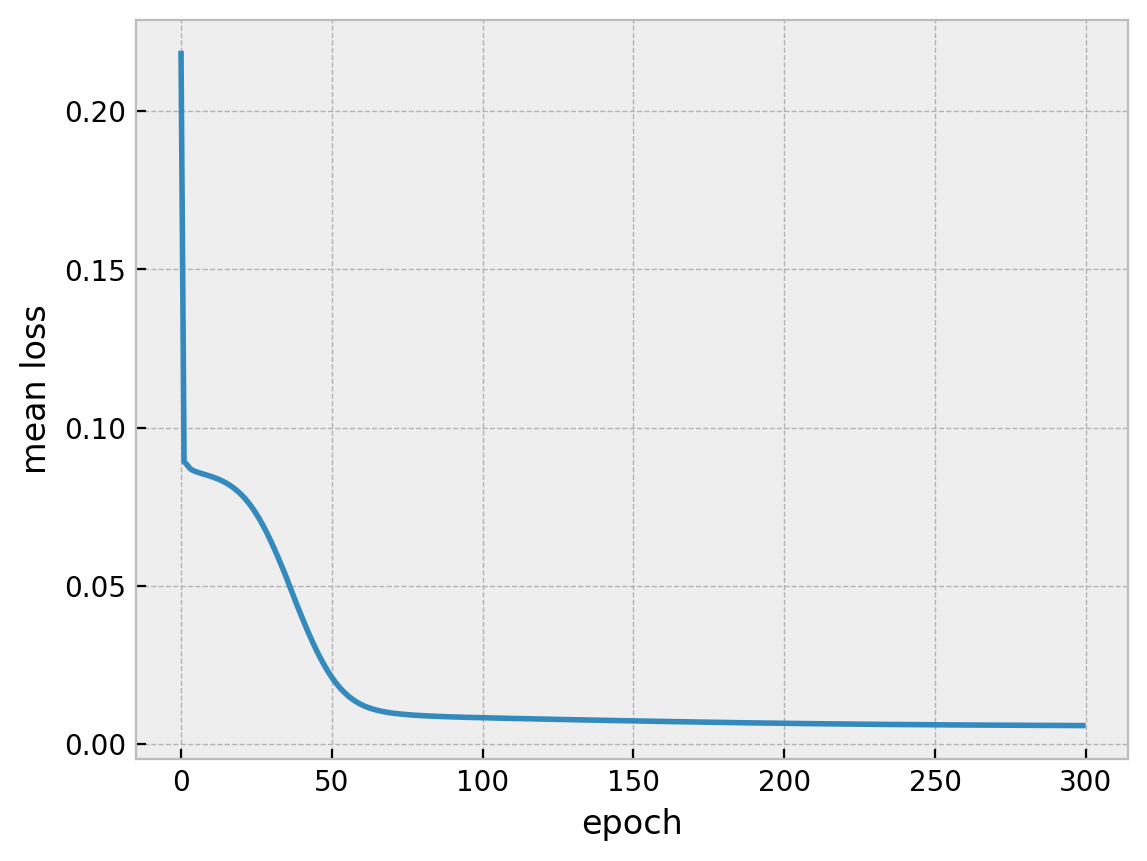

In [7]:
from lecture8 import FeedforwardNN

nn = FeedforwardNN(regression=True, n_iter=300, n_hidden=16, verbose=False, plot=True, relu=True)

nn.fit(Xtrain, Ytrain)

We finally evaluate on the test set and plot the predictions. As you can see, this model also fits the data quite well ($R^2$ is close to 1).

(0.005924936794388094, 0.9348768334878812)

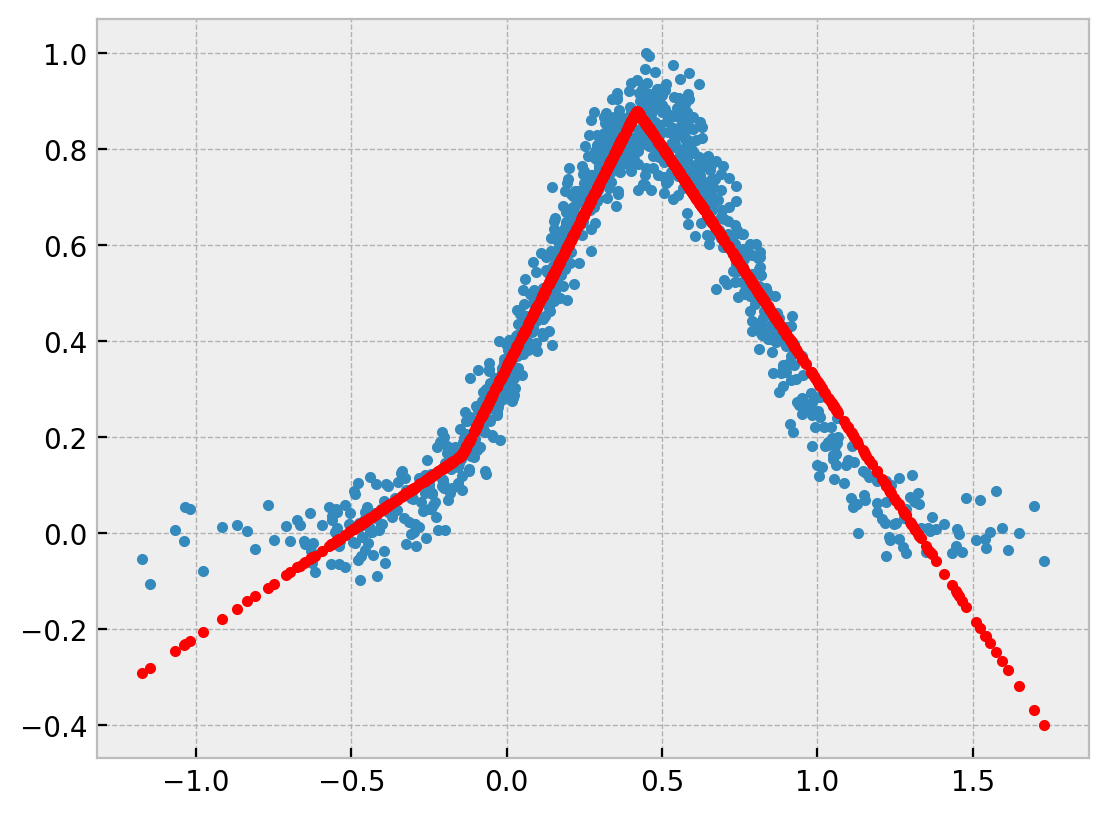

In [8]:
Yguess = nn.predict(Xtest)

plt.plot(Xtest[:,0], Ytest, '.')
plt.plot(Xtest[:,0], Yguess, 'r.')

mean_squared_error(Ytest, Yguess), r2_score(Ytest, Yguess)